In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import functions
import glob as glob
import cartopy.crs as ccrs
import matplotlib as mpl
import matplotlib.colors as mcolors

from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator)
import matplotlib.ticker as mticker
import cmcrameri as cm

In [2]:
fbkdir = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/feedbacks/'
tempdir = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/feedback_input/'

In [3]:
cldtype = 'ALL'
experiments = ['abrupt-0_5xCO2', 'abrupt-2xCO2', 'abrupt-4xCO2']
ds_list = []
dT_list = []
dT_annavg_list = []

interval=30
if interval == 30:
    tslicelist = [slice('1920-01-01', '1949-12-31'), slice('1950-01-01', '1979-12-31'),
                slice('1980-01-01', '2009-12-31'), slice('2010-01-01', '2039-12-31'),
                slice('2040-01-01', '2069-12-31')]
elif interval == 15:
    tslicelist = [slice('1920-01-01', '1934-12-31'), slice('1935-01-01', '1949-12-31'),
                slice('1950-01-01', '1964-12-31'), slice('1965-01-01', '1979-12-31'),
                slice('1980-01-01', '1994-12-31'), slice('1995-01-01', '2009-12-31'),
                slice('2010-01-01', '2024-12-31'), slice('2025-01-01', '2039-12-31'),
                slice('2040-01-01', '2054-12-31'), slice('2055-01-01', '2069-12-31')]
elif interval == 10:
    tslicelist = [slice('1920-01', '1929-12'), slice('1930-01-01', '1939-12-31'),
                slice('1940-01-01', '1949-12-31'), slice('1950-01-01', '1959-12-31'),
                slice('1960-01-01', '1969-12-31'), slice('1970-01-01', '1979-12-31'),
                slice('1980-01-01', '1989-12-31'), slice('1990-01-01', '1999-12-31'),
                slice('2000-01-01', '2009-12-31'), slice('2010-01-01', '2019-12-31'),
                slice('2020-01-01', '2029-12-31'), slice('2030-01-01', '2039-12-31'),
                slice('2040-01-01', '2049-12-31'), slice('2050-01-01', '2059-12-31'),
                slice('2060-01-01', '2069-12-31')]
N = int(150/interval)

pi_temp = xr.open_dataset(tempdir+'tas_piClim_final30years.nc')
pi_temp = pi_temp.groupby('time.month').mean('time')
pi_temp = pi_temp.rename({'month':'time'})
pi_temp_annavg = pi_temp.mean('time')

for exp in experiments:

    fbk_files = glob.glob(fbkdir+'interval'+str(interval)+'/'+cldtype+'_'+exp+'_*')
    fbk_files.sort()
    fbk_ds = xr.open_mfdataset(fbk_files, combine='nested', concat_dim='period')
    ds_list.append(fbk_ds)

    temp_ds = xr.open_dataset(tempdir+'tas_'+exp+'_1920-01-01_2069-12-31.nc')

    temp_annavg = temp_ds.groupby('time.year').mean('time')
    temp_annavg['tas'] = temp_annavg['tas'] - pi_temp_annavg['tas']
    dT_annavg_list.append(temp_annavg)
    
    dT = []
    for tslice in tslicelist:
        temp_slice = temp_ds.sel(time=tslice)
        temp_slice = temp_slice.groupby('time.month').mean('time')
        temp_slice = temp_slice.rename({'month':'time'})
        temp_slice['tas'] = temp_slice['tas'] - pi_temp['tas']
        dT.append(temp_slice)

    dT = xr.concat(dT, dim='period')
    dT_list.append(dT)


ds = xr.concat(ds_list, dim='co2_conc')
ds = ds.assign_coords({'period':np.arange(N)*interval})
ds = ds.assign_coords({'co2_conc':['0.5xCO2', '2xCO2', '4xCO2']})

ds_dT = xr.concat(dT_list, dim='co2_conc')
ds_dT = ds_dT.assign_coords({'period':np.arange(N)*interval})
ds_dT = ds_dT.assign_coords({'co2_conc':['0.5xCO2', '2xCO2', '4xCO2']})

ds_dT_annavg = xr.concat(dT_annavg_list, dim='co2_conc')

In [4]:
clouddir = '/projects/NS9600K/astridbg/arctic-cld-feedbacks/data/other_cloud_vars/'
tempdir = '/projects/NS9600K/astridbg/arctic-cld-feedbacks/data/feedback_input/'
var_list = ['CLDTOT','TGCLDLWP']

In [5]:
# Prepare piClim experiments
exp = 'piClim'
tslice = slice('2040-01-01', '2069-12-31')

pi_temp = xr.open_dataset(tempdir+'tas_piClim_final30years.nc')
pi_temp = functions.computeWeightedMean(pi_temp.mean('time'))
pi_temp = float(pi_temp['tas'].values)

cloud_files = []
for var in var_list: cloud_files.append(clouddir+var+'_'+exp+'.nc')
cloud_files.sort()
print(cloud_files)
cloud_ds = xr.open_mfdataset(cloud_files)

cloud_slice = cloud_ds.sel(time=tslice)
piClim_cloud = cloud_slice.groupby('time.season').mean('time')
piClim_cloud_std = cloud_slice.groupby('time.season').std('time')
piClim_cloud = piClim_cloud.rename({'season':'time'})

['/projects/NS9600K/astridbg/arctic-cld-feedbacks/data/other_cloud_vars/CLDTOT_piClim.nc', '/projects/NS9600K/astridbg/arctic-cld-feedbacks/data/other_cloud_vars/TGCLDLWP_piClim.nc']


In [6]:
experiments = ['abrupt-0_5xCO2', 'abrupt-2xCO2', 'abrupt-4xCO2']
interval = 30
ds_list = []
dT_list = []

interval=30
if interval == 30:
    tslicelist = [slice('1920-01-01', '1949-12-31'), slice('1950-01-01', '1979-12-31'),
                slice('1980-01-01', '2009-12-31'), slice('2010-01-01', '2039-12-31'),
                slice('2040-01-01', '2069-12-31')]
elif interval==15:
    tslicelist = [slice('1920-01-01', '1934-12-31'), slice('1935-01-01', '1949-12-31'),
                slice('1950-01-01', '1964-12-31'), slice('1965-01-01', '1979-12-31'),
                slice('1980-01-01', '1994-12-31'), slice('1995-01-01', '2009-12-31'),
                slice('2010-01-01', '2024-12-31'), slice('2025-01-01', '2039-12-31'),
                slice('2040-01-01', '2054-12-31'), slice('2055-01-01', '2069-12-31')]
elif interval==10:
    tslicelist = [slice('1920-01', '1929-12'), slice('1930-01-01', '1939-12-31'),
            slice('1940-01-01', '1949-12-31'), slice('1950-01-01', '1959-12-31'),
            slice('1960-01-01', '1969-12-31'), slice('1970-01-01', '1979-12-31'),
            slice('1980-01-01', '1989-12-31'), slice('1990-01-01', '1999-12-31'),
            slice('2000-01-01', '2009-12-31'), slice('2010-01-01', '2019-12-31'),
            slice('2020-01-01', '2029-12-31'), slice('2030-01-01', '2039-12-31'),
            slice('2040-01-01', '2049-12-31'), slice('2050-01-01', '2059-12-31'),
            slice('2060-01-01', '2069-12-31')]
N = int(150/interval)

for exp in experiments:
    cloud_files = []
    for var in var_list: cloud_files.append(clouddir+var+'_'+exp+'.nc')
    cloud_files.sort()
    cloud_ds = xr.open_mfdataset(cloud_files)
    
    dT = []
    cloud_list = []
    for tslice in tslicelist:
        cloud_slice = cloud_ds.sel(time=tslice)
        cloud_slice = cloud_slice.groupby('time.season').mean('time')
        cloud_slice = cloud_slice.rename({'season':'time'})
        cloud_list.append(cloud_slice)
    
    ds_cloud = xr.concat(cloud_list, dim='period')
    ds_list.append(ds_cloud)

ds_cloud = xr.concat(ds_list, dim='co2_conc')
ds_cloud = ds_cloud.assign_coords({'period':np.arange(N)*interval})
ds_cloud = ds_cloud.assign_coords({'co2_conc':['0.5xCO2', '2xCO2', '4xCO2']})

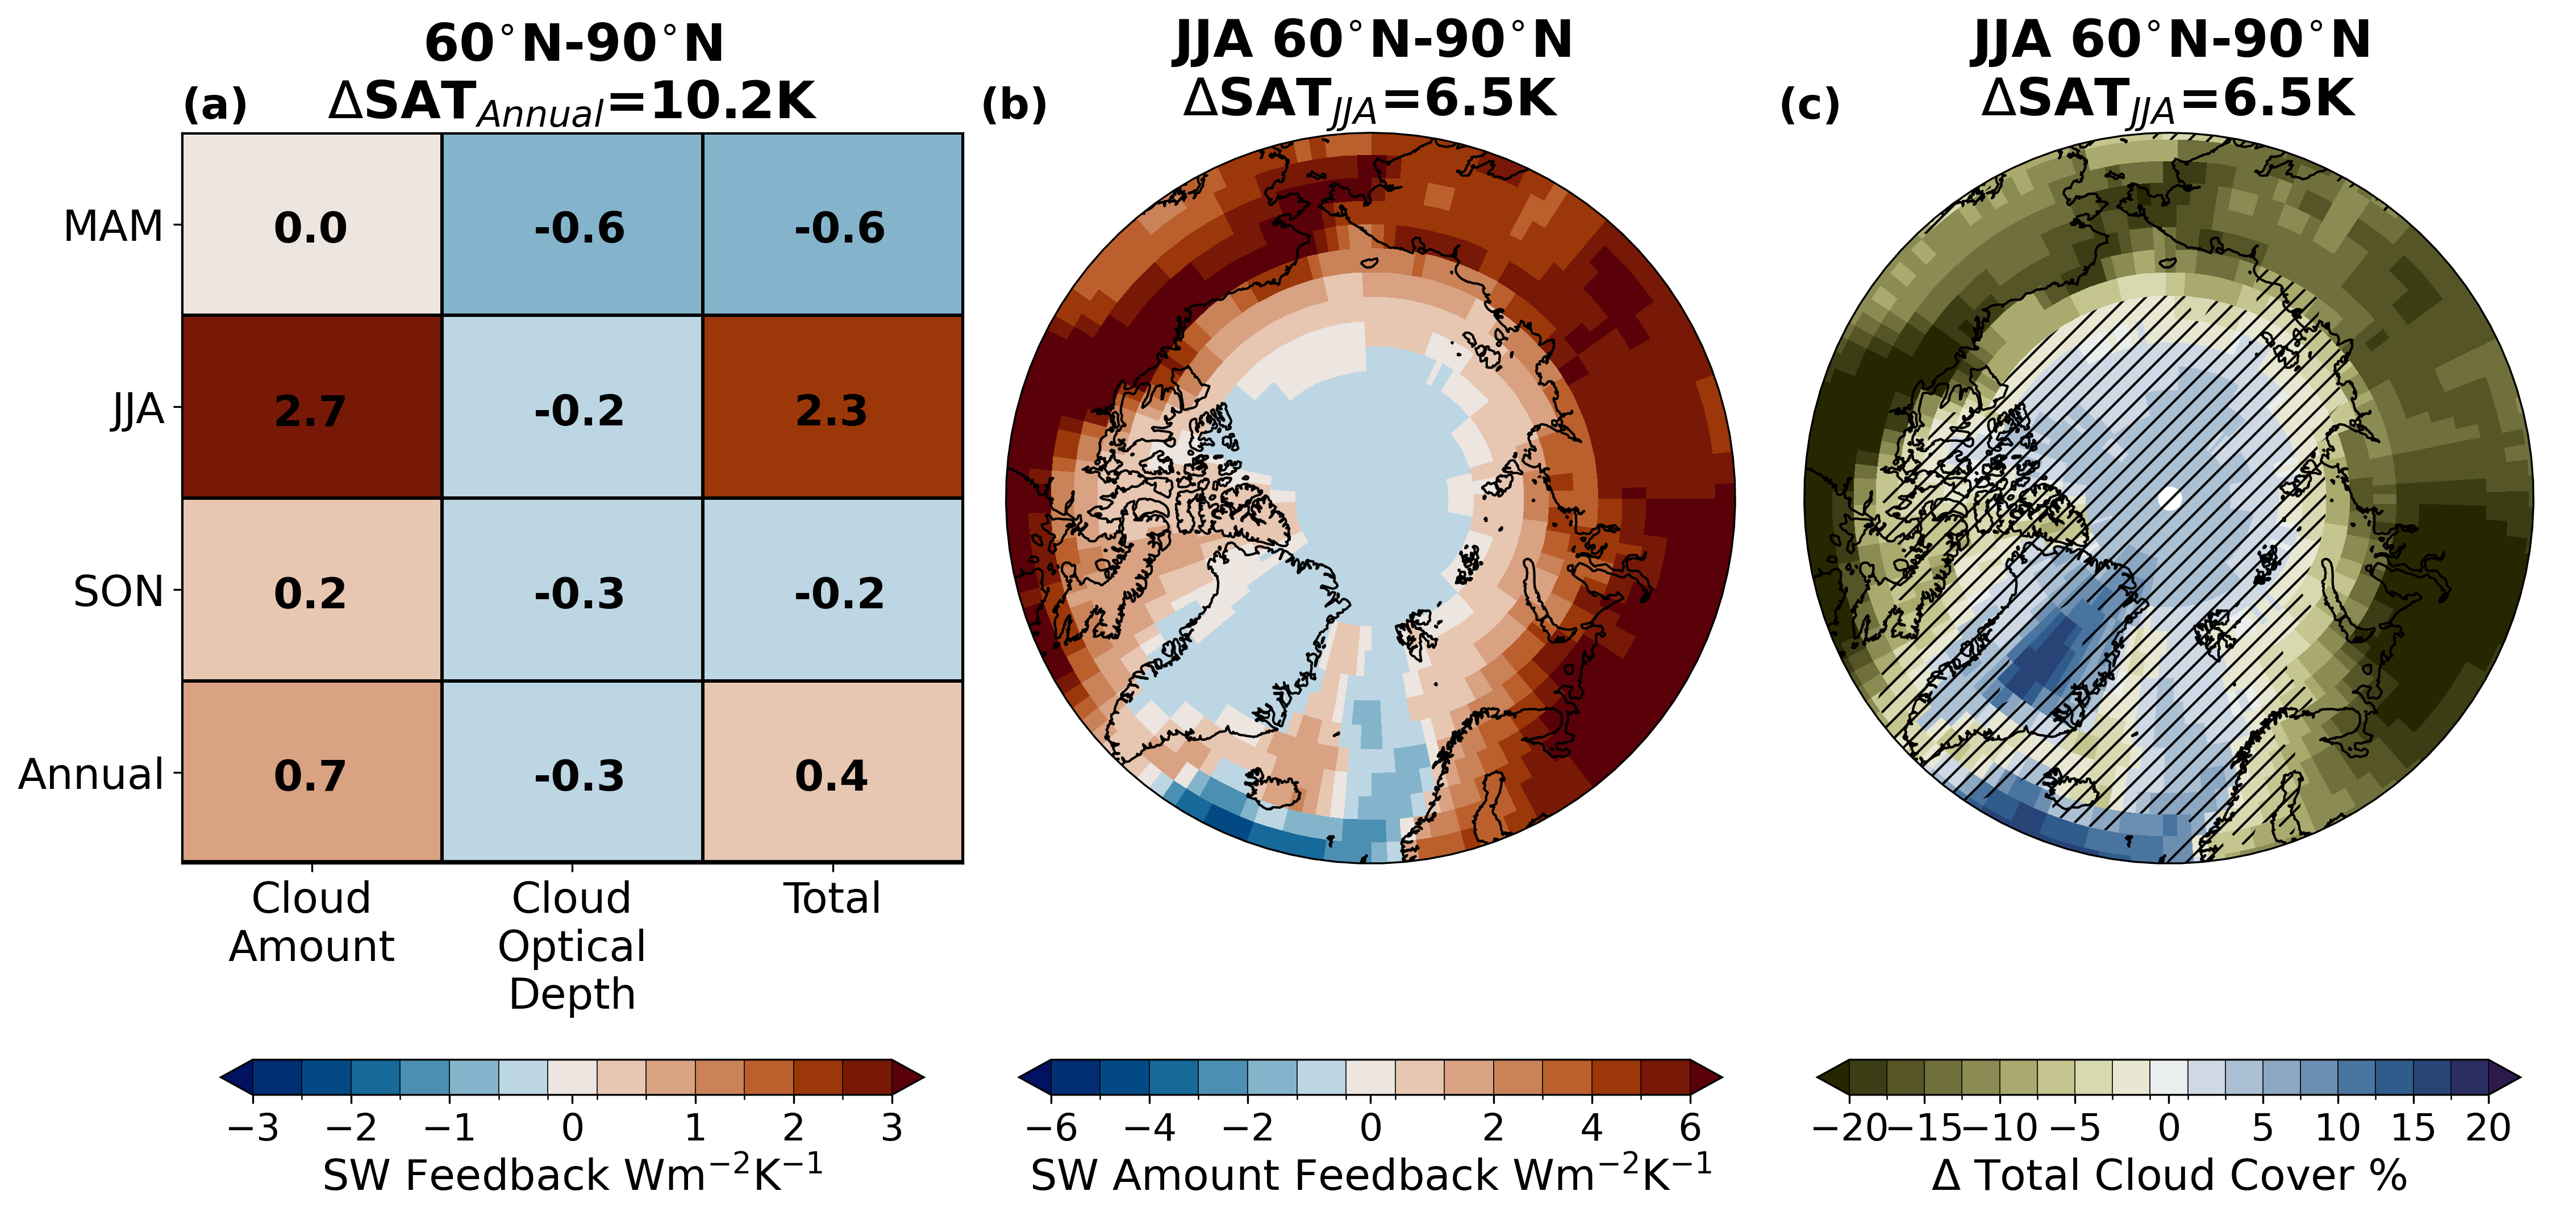

In [7]:
Arctic_limit = 60
period = 120
co2_conc = '4xCO2'

seasons = ['DJF','MAM','JJA','SON']
components = ['SWcld_amt', 'SWcld_tau','SWcld_tot']; component_names = ['Cloud\nAmount','Cloud\nOptical\nDepth', 'Total']

labels = [['(a)','(b)','(c)']]

# Choose subset of feedback variables, while selecting period of interest
var_list = []
for comp in components:
      var_list.append(ds[comp].sel(period=period)) 
feedbacks = xr.merge(var_list)

# Compute seasonal means and annual average
feedbacks_t_avg = [] # for feedbacks
cloud_t_avg = [] # for cloud cover
cloud_piClim_t_avg = [] # for pre-industrial cloud cover
temp_t_avg = [] # for temperature

feedbacks_seasons = feedbacks.groupby('time.season').mean('time')
for season in seasons:
    dT_i = functions.computeSeasonalMean(ds_dT.sel(period=period),season=season)
    
    feedbacks_t_avg.append(feedbacks_seasons.sel(season=season).drop_vars('season'))
    cloud_t_avg.append(ds_cloud.sel(time=season, period=period).drop_vars('time'))
    cloud_piClim_t_avg.append(piClim_cloud.sel(time=season).drop_vars('time'))
    temp_t_avg.append(dT_i)
feedbacks_t_avg.append(feedbacks.mean('time'))
cloud_t_avg.append(ds_cloud.sel(period=period).mean('time'))
cloud_piClim_t_avg.append(piClim_cloud.mean('time'))
temp_t_avg.append(ds_dT.sel(period=period).mean('time'))

feedbacks_t_avg = xr.concat(feedbacks_t_avg,dim='time')
feedbacks_t_avg = feedbacks_t_avg.assign_coords({'time':seasons+['Annual']})
feedbacks_t_avg = feedbacks_t_avg.isel(time=slice(1,5)) # Drop DJF

cloud_t_avg = xr.concat(cloud_t_avg,dim='time')
cloud_t_avg = cloud_t_avg.assign_coords({'time':seasons+['Annual']})

cloud_piClim_t_avg = xr.concat(cloud_piClim_t_avg,dim='time')
cloud_piClim_t_avg = cloud_piClim_t_avg.assign_coords({'time':seasons+['Annual']})

temp_t_avg = xr.concat(temp_t_avg,dim='time')
temp_t_avg = temp_t_avg.assign_coords({'time':seasons+['Annual']})

# Compute Arctic spatial averages
feedbacks_Arctic = functions.computeWeightedMean(feedbacks_t_avg.sel(lat=slice(Arctic_limit, 90)))
temp_Arctic = functions.computeWeightedMean(temp_t_avg.sel(lat=slice(Arctic_limit, 90)))

# Create figure
fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(15, 7),dpi=300,constrained_layout=True)
# Remove axis from map plots
axs['(b)'].axis('off')
axs['(c)'].axis('off')
# Add new subplots with Arctic map projection
ax2 = fig.add_subplot(1, 3, 2, projection=ccrs.Orthographic(0, 90))
ax3 = fig.add_subplot(1, 3, 3, projection=ccrs.Orthographic(0, 90))

# Row 1: spatially averaged feedback plots
uneven_levels = [-3,-2.5,-2,-1.5,-1,-0.5,-0.1,0.1,0.5,1,1.5,2,2.5,3]
cmap_rb = cm.cm.vik
colors = cmap_rb(np.linspace(0, 1, len(uneven_levels)+1))
cmap, norm = mcolors.from_levels_and_colors(uneven_levels, colors,extend='both')

ax = axs['(a)']
d_SAT = temp_Arctic['tas'].sel(time='Annual',co2_conc=co2_conc).values
feedbacks_i = feedbacks_Arctic.sel(co2_conc=co2_conc).to_dataarray()
X = np.arange(len(components))
Y = np.arange(len(feedbacks_Arctic.time))
cmap = ax.pcolormesh(X, Y, feedbacks_i.T, cmap=cmap,norm=norm,edgecolor='k',linewidths=1)
ax.hlines(3.5,X[0]-0.5,X[-1]+0.5,color='k',linewidth=3)
ax.set_xticks(np.arange(len(components)))
ax.set_xticklabels(component_names,fontsize=18)
ax.set_yticks(np.arange(len(feedbacks_Arctic.time)))
ax.set_yticklabels(feedbacks_Arctic.time.values, fontsize=18)
for x in X:
    for y in Y:
        avg_feedback = np.round(float(feedbacks_i[x][y]),1)
        if np.abs(avg_feedback) < 0.1:
            avg_feedback = np.abs(avg_feedback)
        ax.text(x-0.15, y+0.1, str(avg_feedback), fontsize=18, fontweight='bold')
ax.invert_yaxis()
ax.set_title('60$^{\circ}$N-90$^{\circ}$N'+'\n$\Delta$SAT$_{Annual}$='+str(np.round(d_SAT,1))+'K', fontsize=22,fontweight='bold')

cb = fig.colorbar(cmap, ax=ax, location='bottom', ticks=[-3,-2,-1,0,1,2,3], drawedges=True,extend='both',shrink=0.9)

cb.set_label(label='SW Feedback Wm$^{-2}$K$^{-1}$',fontsize=18)
cb.ax.tick_params(labelsize=16)

# Row 2: spatial distribution of cloud amount feedback
uneven_levels = [-6,-5,-4,-3,-2,-1,-0.1,0.1,1,2,3,4,5,6]
cmap_rb = cm.cm.vik
colors = cmap_rb(np.linspace(0, 1, len(uneven_levels)+1))
cmap, norm = mcolors.from_levels_and_colors(uneven_levels, colors,extend='both')

for ax,co2_conc in zip([ax2], [co2_conc]):
    functions.polarCentral_set_latlim([60,90], ax)
    data = feedbacks_t_avg['SWcld_amt'].sel(time='JJA', co2_conc=co2_conc)
    map = data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), 
                                        cmap=cmap, norm=norm,
                                        add_colorbar=False)
    d_SAT_JJA = temp_Arctic['tas'].sel(time='JJA',co2_conc=co2_conc).values
    ax.set_title('JJA 60$^{\circ}$N-90$^{\circ}$N'+'\n$\Delta$SAT$_{JJA}$='+str(np.round(d_SAT_JJA,1))+'K', fontsize=22,fontweight='bold')
    ax.coastlines()

cb = fig.colorbar(map, ax=ax, location='bottom', ticks=[-6,-4,-2,0,2,4,6], drawedges=True,shrink=0.9)
cb.set_label(label='SW Amount Feedback Wm$^{-2}$K$^{-1}$',fontsize=18)
#cb.set_ticks(ticks=[-6,-4,-2,-0.1,0.1,2,4,6], labels=[-6,-4,-2,-0.1,0.1,2,4,6])
cb.ax.tick_params(labelsize=16)


# Row 3: spatial distribution of cloud cover change
uneven_levels = [-20,-17.5,-15,-12.5,-10,-7.5,-5,-2.5,-0.1,0.1,2.5,5,7.5,10,12.5,15,17.5,20]
cmap_rb = cm.cm.broc_r
colors = cmap_rb(np.linspace(0, 1, len(uneven_levels)+1))
cmap, norm = mcolors.from_levels_and_colors(uneven_levels, colors,extend='both')

for ax,co2_conc in zip([ax3], [co2_conc]):
    functions.polarCentral_set_latlim([60,90], ax)
    data = cloud_t_avg['CLDTOT'].sel(time='JJA',co2_conc=co2_conc) - cloud_piClim_t_avg['CLDTOT'].sel(time='JJA') # Get cloud fraction change from pre-industrial climate
    data = data*100 # Convert cloud fraction to percentage
    map = data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), 
                                        cmap=cmap,norm=norm,
                                        add_colorbar=False)
    d_SAT_JJA = temp_Arctic['tas'].sel(time='JJA',co2_conc=co2_conc).values
    ax.set_title('JJA 60$^{\circ}$N-90$^{\circ}$N'+'\n$\Delta$SAT$_{JJA}$='+str(np.round(d_SAT_JJA,1))+'K', fontsize=22,fontweight='bold')
    ax.coastlines()
    hatch_density=3
    hatch_style='/'
    insignificant_data = functions.xr_add_cyclic_point(np.abs(data) < piClim_cloud_std['CLDTOT'].sel(season='JJA')*100)
    hatch = ax.contourf(insignificant_data.lon, insignificant_data.lat, insignificant_data, transform=ccrs.PlateCarree(), colors='none', levels=[.5,1.5], hatches=[hatch_density*hatch_style, hatch_density*hatch_style])    
cb = fig.colorbar(map, ax=ax, location='bottom', ticks=[-20,-15,-10,-5,0,5,10,15,20], drawedges=True,shrink=0.9)

cb.set_label(label='$\Delta$ Total Cloud Cover %',fontsize=18)
cb.ax.tick_params(labelsize=16)

# Label subplots
for label, ax in axs.items():
    ax.set_title(label, loc='left', fontsize=18,fontweight='bold')

fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig1.png')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig1.pdf')